# Two-qubit gates from FSim interactions

Jasper Sands · `cirq_fsim_compiler` 0.4

1. The FSim gate and the decomposition template
2. Free angles: one FSim for each standard gate
3. A calibrated coupler: how many Sycamore gates each target needs
4. Two solvers for the same loss: L-BFGS on angles and Riemannian descent on U(2)
5. Recompiling after calibration drift
6. Whole circuits: three-qubit gates, block consolidation and routing onto a line
7. OpenQASM 3 out and back in

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
import cirq
from cirq_fsim_compiler import (
    fsim_matrix_np, haar_random_unitary, DifferentiableFSimSynthesizer, synthesize_unitary_to_fsim,
    CouplerCalibration, SycamoreCalibrationMap, compile_to_fsim, decompose_toffoli_to_sycamore,
    decompose_fredkin_to_sycamore, decompose_qft3_to_sycamore, qft_unitary,
    export_to_openqasm3, parse_openqasm3, __version__,
)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
print("cirq_fsim_compiler", __version__, "| cirq", cirq.__version__)
fid = lambda u, v: abs(np.trace(u.conj().T @ v))**2 / u.shape[0]**2

cirq_fsim_compiler 0.4.0 | cirq 1.7.0


## 1. The FSim gate

$\mathrm{FSim}(\theta,\varphi) = \begin{pmatrix}1&&&\\&\cos\theta&-i\sin\theta&\\&-i\sin\theta&\cos\theta&\\&&&e^{-i\varphi}\end{pmatrix}$ — an XY swap angle $\theta$ and a conditional phase $\varphi$. Sycamore's native gate is $\theta=\pi/2,\ \varphi=\pi/6$.

In [2]:
print(np.round(fsim_matrix_np(np.pi/2, np.pi/6), 3))
print("matches cirq.FSimGate:", np.allclose(fsim_matrix_np(np.pi/2, np.pi/6), cirq.unitary(cirq.FSimGate(np.pi/2, np.pi/6))))

[[1.   +0.j  0.   +0.j  0.   +0.j  0.   +0.j ]
 [0.   +0.j  0.   +0.j  0.   -1.j  0.   +0.j ]
 [0.   +0.j  0.   -1.j  0.   +0.j  0.   +0.j ]
 [0.   +0.j  0.   +0.j  0.   +0.j  0.866-0.5j]]
matches cirq.FSimGate: True


## 2. Free-angle synthesis: every named gate is a single FSim

gate     stages  1-F        (θ, φ)
CNOT         1   0.0e+00   (-0.000, +3.142)
CZ           1   0.0e+00   (+0.000, +3.142)
iSWAP        1   1.3e-15   (-1.571, -0.000)
√iSWAP       1   0.0e+00   (-2.356, +0.000)
SWAP         1   0.0e+00   (+1.571, -3.142)
random U(4): stages 2, 1-F = 0.0e+00


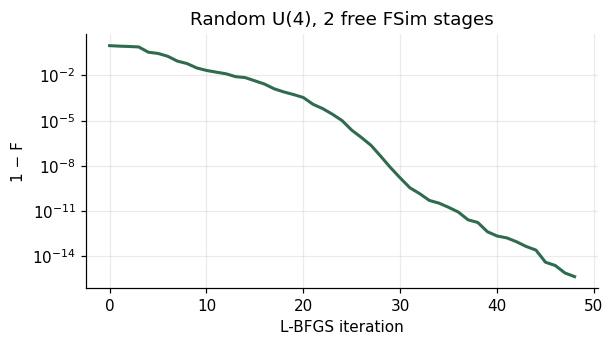

In [3]:
synth = DifferentiableFSimSynthesizer(target_infidelity=1e-9, seed=1)
gates = {"CNOT": cirq.CNOT, "CZ": cirq.CZ, "iSWAP": cirq.ISWAP, "√iSWAP": cirq.SQRT_ISWAP, "SWAP": cirq.SWAP}
print(f"{'gate':8s} stages  1-F        (θ, φ)")
for name, g in gates.items():
    r = synth.decompose(cirq.unitary(g), n_restarts=4)
    print(f"{name:8s} {r.n_stages:5d}   {r.infidelity:.1e}   " + ", ".join(f"({t:+.3f}, {p:+.3f})" for t, p in r.fsim_angles))
r = synth.decompose(haar_random_unitary(4, seed=7), n_restarts=6, max_iter=400)
print(f"random U(4): stages {r.n_stages}, 1-F = {r.infidelity:.1e}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.semilogy(np.maximum(r.loss_history, 1e-16), lw=2, color="#2f6b4f"); ax.set_xlabel("L-BFGS iteration"); ax.set_ylabel("1 − F"); ax.set_title("Random U(4), 2 free FSim stages")
plt.show()

## 3. Calibrated native gate

On hardware the coupler provides *one* gate. Freezing $(\theta,\varphi)$ to the calibrated values and optimising only the single-qubit dressings gives the minimum number of native applications.

In [4]:
for cal_name, cal in [("Sycamore FSim(π/2, π/6)", CouplerCalibration.sycamore()), ("√iSWAP FSim(π/4, 0)", CouplerCalibration.sqrt_iswap())]:
    print(cal_name)
    for name, g in list(gates.items()) + [("random U(4)", None)]:
        u = haar_random_unitary(4, seed=7) if g is None else cirq.unitary(g)
        r = synth.decompose(u, n_restarts=6, max_iter=300, calibration=cal)
        print(f"   {name:12s} → {r.n_stages} native gate(s), 1-F = {r.infidelity:.1e}")

Sycamore FSim(π/2, π/6)
   CNOT         → 2 native gate(s), 1-F = 0.0e+00
   CZ           → 2 native gate(s), 1-F = 4.4e-16
   iSWAP        → 3 native gate(s), 1-F = 0.0e+00
   √iSWAP       → 2 native gate(s), 1-F = 8.9e-16
   SWAP         → 3 native gate(s), 1-F = 4.4e-16
   random U(4)  → 3 native gate(s), 1-F = 0.0e+00
√iSWAP FSim(π/4, 0)
   CNOT         → 2 native gate(s), 1-F = 2.2e-16
   CZ           → 2 native gate(s), 1-F = 0.0e+00
   iSWAP        → 2 native gate(s), 1-F = 0.0e+00
   √iSWAP       → 1 native gate(s), 1-F = 0.0e+00
   SWAP         → 3 native gate(s), 1-F = 3.2e-12
   random U(4)  → 3 native gate(s), 1-F = 1.1e-15


## 4. Euclidean vs Riemannian solvers

Both minimise the same loss. The Euclidean solver runs L-BFGS-B on Euler angles; the Riemannian solver keeps each dressing $V_j\in U(2)$ and moves along the manifold with Cayley retractions, so every iterate is exactly unitary.

euclidean : stages 2, 1-F = 0.0e+00, 40 iterations, 1.51 s
riemannian: stages 2, 1-F = 6.4e-15, 81 iterations, 2.87 s
riemannian result unitary to 4.4e-15


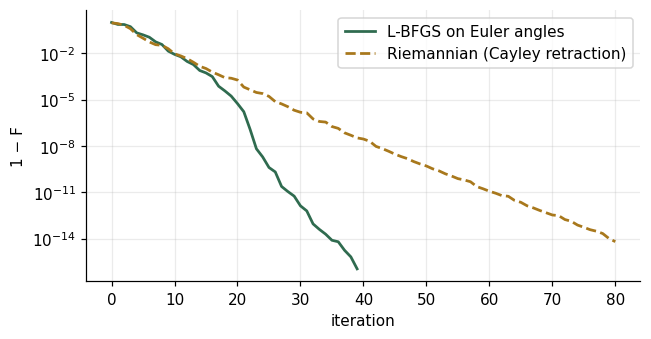

In [5]:
u = haar_random_unitary(4, seed=21)
t0 = time.time(); e = DifferentiableFSimSynthesizer(target_infidelity=1e-10, seed=1).decompose(u, n_restarts=4, max_iter=400); te = time.time() - t0
t0 = time.time(); rm = DifferentiableFSimSynthesizer(target_infidelity=1e-10, seed=1, method="riemannian").decompose(u, n_restarts=4, max_iter=800); tr = time.time() - t0
print(f"euclidean : stages {e.n_stages}, 1-F = {e.infidelity:.1e}, {len(e.loss_history)} iterations, {te:.2f} s")
print(f"riemannian: stages {rm.n_stages}, 1-F = {rm.infidelity:.1e}, {len(rm.loss_history)} iterations, {tr:.2f} s")
U = rm.synthesized_unitary
print("riemannian result unitary to", f"{np.abs(U.conj().T @ U - np.eye(4)).max():.1e}")
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.semilogy(np.maximum(e.loss_history, 1e-16), label="L-BFGS on Euler angles", lw=1.8, color="#2f6b4f")
ax.semilogy(np.maximum(rm.loss_history, 1e-16), label="Riemannian (Cayley retraction)", lw=1.8, color="#a8781c", ls="--")
ax.set_xlabel("iteration"); ax.set_ylabel("1 − F"); ax.legend(); plt.show()

## 5. Calibration drift

In [6]:
cm = SycamoreCalibrationMap(seed=3)
for edge in [(0, 1), (1, 2), (2, 3)]:
    cal = cm.get_coupler(*edge)
    r = synth.decompose(cirq.unitary(cirq.CZ), n_restarts=6, calibration=cal)
    print(f"edge {edge}: native FSim({cal.theta_cal:.4f}, {cal.phi_cal:.4f}) → CZ in {r.n_stages} gates, 1-F = {r.infidelity:.1e}")
drifted = cm.perturb(seed=9)
cal2 = drifted.get_coupler(0, 1)
r2 = synth.decompose(cirq.unitary(cirq.CZ), n_restarts=6, calibration=cal2)
print(f"after drift: FSim({cal2.theta_cal:.4f}, {cal2.phi_cal:.4f}) → recompiled CZ 1-F = {r2.infidelity:.1e}")

edge (0, 1): native FSim(1.6116, 0.4853) → CZ in 2 gates, 1-F = 2.2e-16
edge (1, 2): native FSim(1.5792, 0.5151) → CZ in 2 gates, 1-F = 4.4e-16
edge (2, 3): native FSim(1.5617, 0.5204) → CZ in 2 gates, 1-F = 2.2e-16
after drift: FSim(1.5956, 0.4889) → recompiled CZ 1-F = 8.9e-16


## 6. Whole circuits and three-qubit gates

In [7]:
q = cirq.LineQubit.range(3)
circuit = cirq.Circuit(cirq.H(q[0]), cirq.CNOT(q[0], q[1]), cirq.CCNOT(*q), cirq.ISWAP(q[1], q[2]))
compiled = compile_to_fsim(circuit, target_infidelity=1e-8)
print("max qubits per op:", max(len(op.qubits) for op in compiled.all_operations()),
      "| FSim gates:", sum(isinstance(op.gate, cirq.FSimGate) for op in compiled.all_operations()),
      "| fidelity:", round(fid(cirq.unitary(compiled), cirq.unitary(circuit)), 10))
for name, fn, ref in [("Toffoli", decompose_toffoli_to_sycamore, cirq.unitary(cirq.CCNOT(*q))),
                      ("Fredkin", decompose_fredkin_to_sycamore, cirq.unitary(cirq.CSWAP(*q))),
                      ("QFT3", decompose_qft3_to_sycamore, qft_unitary(3))]:
    c = fn(*q, target_infidelity=1e-8)
    print(f"{name:8s}: {sum(isinstance(op.gate, cirq.FSimGate) for op in c.all_operations())} FSim, {len(c)} moments, fidelity {fid(cirq.unitary(c), ref):.10f}")
print(decompose_qft3_to_sycamore(*q).to_text_diagram()[:900])

max qubits per op: 2 | FSim gates: 8 | fidelity: 1.0
Toffoli : 5 FSim, 35 moments, fidelity 1.0000000000
Fredkin : 7 FSim, 46 moments, fidelity 1.0000000000
QFT3    : 4 FSim, 28 moments, fidelity 1.0000000000
0: ───Rz(0.5π)─────Rx(-0.5π)───Rz(0.421π)────FSim(1.36e-09π, -0.5π)───Rz(-0.225π)───Rx(-π)─────Rz(-0.804π)───Rz(0.698π)───Rx(0)───Rz(0.549π)───FSim(1.35e-10π, 0.25π)───Rz(-0.233π)───Rx(0)───Rz(-0.763π)───Rz(0.932π)───Rx(0.394π)───Rz(-0.11π)─────────────────────────────────────────────────────────────────────────────────────────────────────FSim(0.5π, -1.0π)───Rz(-0.342π)───Rx(0)─────────Rz(-0.894π)───
                                             │                                                                                                 │                                                                                                                                                                                                     │
1: ───Rz(0.797π)───Rx(-π)──────Rz(0.354π)───

On calibrated Sycamore couplers every CNOT costs two gates. Merging each run of operations on the same pair of qubits into one 4×4 block before synthesis lets a block such as CNOT·(T⊗T†)·CNOT cost what its KAK class costs. Routing onto a line inserts SWAPs, which consolidation then folds into neighbouring blocks where it can. (For reference, a Toffoli needs at least five two-qubit gates of any kind.)

In [8]:
import networkx as nx
from cirq_fsim_compiler.cirq_transformer import compile_circuit_to_sycamore_fsim
from cirq_fsim_compiler.toffoli_decomposer import toffoli_circuit, fredkin_circuit, ccz_circuit, qft3_circuit
nominal = lambda: SycamoreCalibrationMap(seed=0, theta_drift_std=0.0, phi_drift_std=0.0)
line = nx.Graph([(q[0], q[1]), (q[1], q[2])])
count = lambda c: sum(isinstance(op.gate, cirq.FSimGate) for op in c.all_operations())
print("gate      per gate   consolidated   on a line")
for name, build in [("Toffoli", toffoli_circuit), ("Fredkin", fredkin_circuit), ("CCZ", ccz_circuit), ("QFT3", qft3_circuit)]:
    c = build(*q)
    a = count(compile_circuit_to_sycamore_fsim(c, calibration_map=nominal(), consolidate=False))
    b = count(compile_circuit_to_sycamore_fsim(c, calibration_map=nominal()))
    r = count(compile_circuit_to_sycamore_fsim(c, calibration_map=nominal(), device_graph=line))
    print(f"{name:8s}  {a:8d}   {b:12d}   {r:9d}")

gate      per gate   consolidated   on a line
Toffoli         12             10          14
Fredkin         16             12          16
CCZ             12             10          14
QFT3             9              9          13


## 7. OpenQASM 3 out and back in

The exporter defines `gate fsim` with standard gates, so any OpenQASM 3 simulator can run the file, and writes measurements to bit registers. The importer is a small recursive-descent parser rather than a set of regular expressions. It handles named registers, user gate definitions (including nested ones), broadcasting and parameter expressions, and it evaluates those expressions itself instead of calling `eval`.

In [9]:
c = compile_to_fsim(cirq.Circuit(cirq.H(q[0]), cirq.CNOT(q[0], q[1])), target_infidelity=1e-9)
c.append(cirq.measure(q[0], q[1], key="m"))
text = export_to_openqasm3(c)
print(text[text.index("qubit["):])
back = parse_openqasm3(text)
strip = lambda circ: cirq.Circuit(op for op in circ.all_operations() if not cirq.is_measurement(op))
print("round-trip fidelity:", round(fid(cirq.unitary(strip(back)), cirq.unitary(strip(c))), 12))

program = "\n".join([
    'OPENQASM 3.0;',
    'include "stdgates.inc";',
    'gate rzz(t) a, b { cx a, b; rz(t) b; cx a, b; }',
    'gate layer(t) a, b, c { rzz(t) a, b; rzz(t / 2) b, c; }',
    'qubit[3] reg;',
    'bit[3] out;',
    'h reg;',
    'layer(pi / 3) reg[0], reg[1], reg[2];',
    'out = measure reg;',
])
print(parse_openqasm3(program))
from cirq_fsim_compiler.openqasm3_io import QasmParseError
try:
    parse_openqasm3('qubit q; rx(__import__("os").getcwd()) q;')
except QasmParseError as err:
    print("rejected:", err)

qubit[2] q;
bit[2] m;

rz(1.570796331) q[0];
rz(4.712388975) q[1];
rx(4.712388984) q[0];
rx(-1.570796332) q[1];
rz(1.758974444) q[0];
rz(2.160512788) q[1];
fsim(1.141546109e-09, 3.141592652) q[0], q[1];
rz(1.193161911) q[0];
rz(0.9810798723) q[1];
rx(3.141592658) q[0];
rx(1.570796322) q[1];
rz(-1.760252623) q[0];
rz(1.570796327) q[1];
m[0] = measure q[0];
m[1] = measure q[1];

round-trip fidelity: 1.0
0: ───H───@────────────────@───M('out[0]')──────────────────────────────────
          │                │
1: ───H───X───Rz(0.333π)───X───@──────────────────────────@───M('out[1]')───
                               │                          │
2: ───H────────────────────────X─────────────Rz(0.167π)───X───M('out[2]')───
rejected: line 1: unexpected character '.'
